# Lab: Logistic Loss (Log-Loss) e Regressione Logistica con scikit-learn

Obiettivo: capire cos’è la **logistic loss** (detta anche **log-loss** o **cross-entropy binaria**) e perché è la loss “giusta” per la classificazione binaria.

Useremo librerie note:
- `numpy`
- `matplotlib`
- `scikit-learn`

Cosa faremo:
1. Definire la log-loss per un singolo esempio e per un dataset.
2. Visualizzare la loss nei casi tipici (predizione corretta/errata, alta/bassa confidenza).
3. Collegare la log-loss alle probabilità prodotte da `LogisticRegression` (scikit-learn).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score

%matplotlib inline


## 1) Log-loss per un singolo esempio

1) Log-loss per un singolo esempio

In classificazione binaria, definiamo:

y ∈ {0,1} = classe vera (target reale)
p ∈ (0,1) = probabilità stimata che y = 1

La log-loss per un singolo esempio è:
ℓ(y, p) = − [ y · log(p) + (1 − y) · log(1 − p) ]

2) Interpretazione caso per caso
Caso 1: y = 1
ℓ(1, p) = − log(p)

quindi:
se p è vicino a 1 → log(p) ≈ 0 → loss piccola
se p è vicino a 0 → log(p) → −∞ → loss molto grande

Caso 2: y = 0
ℓ(0, p) = − log(1 − p)

quindi:
se p è vicino a 0 → log(1 − p) ≈ 0 → loss piccola
se p è vicino a 1 → log(1 − p) → −∞ → loss molto grande

3) Forma equivalente più compatta
La stessa formula può essere scritta come:
ℓ(y, p) = − y log(p) − (1 − y) log(1 − p)

4) Collegamento con la regressione logistica
Nella regressione logistica:
p = 1 / (1 + e^(−(w·x + b)))

Quindi la loss dipende indirettamente da:
w (pesi)
b (intercetta)
Il training del modello consiste nel trovare w e b che minimizzano la log-loss totale.

5) Intuizione fondamentale

La log-loss penalizza molto le previsioni sicure ma sbagliate.

Esempio:
y = 1, p = 0.9 → loss piccola
y = 1, p = 0.01 → loss enorme

Questo spinge il modello a stimare probabilità corrette.


In [2]:
def logistic_loss_single(y, p, eps=1e-15):
    # eps evita log(0)
    p = np.clip(p, eps, 1 - eps)
    return -(y*np.log(p) + (1-y)*np.log(1-p))

# Test rapido
for (y, p) in [(1, 0.9), (1, 0.1), (0, 0.1), (0, 0.9)]:
    print(f"y={y}, p={p} -> loss={logistic_loss_single(y,p):.4f}")


y=1, p=0.9 -> loss=0.1054
y=1, p=0.1 -> loss=2.3026
y=0, p=0.1 -> loss=0.1054
y=0, p=0.9 -> loss=2.3026


## 2) Come cambia la loss al variare di p

Tracciamo la loss in funzione di \(p\) per i due casi:
- \(y=1\)
- \(y=0\)

Cosa aspettarsi:
- per \(y=1\), la loss esplode quando \(p \to 0\)
- per \(y=0\), la loss esplode quando \(p \to 1\)


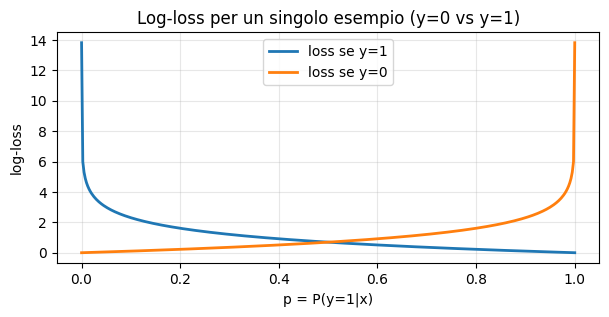

In [3]:
p = np.linspace(1e-6, 1-1e-6, 400)

loss_y1 = logistic_loss_single(1, p)
loss_y0 = logistic_loss_single(0, p)

plt.figure(figsize=(7,3))
plt.plot(p, loss_y1, linewidth=2, label="loss se y=1")
plt.plot(p, loss_y0, linewidth=2, label="loss se y=0")
plt.xlabel("p = P(y=1|x)")
plt.ylabel("log-loss")
plt.title("Log-loss per un singolo esempio (y=0 vs y=1)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 3) Tre casi “didattici” (numeri semplici)

Vediamo tre casi tipici:

1. **Corretta e sicura**: \(y=1\), \(p=0.9\) → loss bassa
    il modello dice: "sono sicuro al 90% che sia classe 1"
    la classe vera è effettivamente 1
quindi è:
    corretta 
    sicura
   
3. **Errata e sicura**: \(y=1\), \(p=0.1\) → loss alta
    il modello dice: "sono sicuro al 90% che NON sia classe 1"
    ma la classe vera è 1
quindi è:
    errata
    ma molto sicura 
Questo è il caso peggiore.
    Loss molto alta.

Perché il modello era molto convinto ma ha sbagliato.

4. **Incerta**: \(y=1\), \(p=0.5\) → loss intermedia  
il modello dice: "non sono sicuro"
    probabilità 50%
quindi è:
    incerta 
    non particolarmente buona, ma nemmeno catastrofica
Loss intermedia.

Nota: la log-loss “punisce” tantissimo le predizioni **sicure ma sbagliate**.


In [4]:
cases = [
    ("Corretta e sicura", 1, 0.9),
    ("Errata e sicura",   1, 0.1),
    ("Incerta (50%)",     1, 0.5),
]

for name, y, p0 in cases:
    print(f"{name:18s} | y={y} p={p0} -> loss={logistic_loss_single(y,p0):.4f}")


Corretta e sicura  | y=1 p=0.9 -> loss=0.1054
Errata e sicura    | y=1 p=0.1 -> loss=2.3026
Incerta (50%)      | y=1 p=0.5 -> loss=0.6931


## 4) Log-loss media su un dataset

Su un dataset con N esempi, la log-loss media è:

Su un dataset con N esempi, la log-loss media è:

LogLoss = − (1/N) * Σ [ yi * log(pi) + (1 − yi) * log(1 − pi) ]

dove:

N = numero totale di esempi

yi = classe vera dell’esempio i (0 oppure 1)

pi = probabilità stimata dal modello che yi = 1

Scikit-learn fornisce `log_loss(y_true, y_proba)`.

Attenzione: per `log_loss` servono le **probabilità**, non le classi 0/1.
Perché serve predict_proba e non predict

Questo è corretto:
y_proba = model.predict_proba(X)[:,1]
log_loss(y, y_proba)


Questo è sbagliato:
y_pred = model.predict(X)
log_loss(y, y_pred)
Perché predict() restituisce solo 0 o 1, non probabilità.


In [5]:
y_true = np.array([0, 0, 1, 1])
p_pred = np.array([0.1, 0.4, 0.6, 0.9])  # probabilità per la classe 1

print("Log-loss (manuale):", np.mean([logistic_loss_single(y, p) for y, p in zip(y_true, p_pred)]))
print("Log-loss (sklearn):", log_loss(y_true, p_pred))


Log-loss (manuale): 0.30809306971190853
Log-loss (sklearn): 0.30809306971190853


## 5) Collegamento con la Regressione Logistica (scikit-learn)

La regressione logistica produce:


p(x) = P(y=1| x)

e durante l’addestramento sceglie i parametri (w, b) per minimizzare la **log-loss** (più precisamente: massimizzare la verosimiglianza, che è equivalente).

Qui facciamo un esempio con una sola variabile.


In [20]:
# Dataset semplice (1 variabile)
x = np.array([0., 1, 2, 3, 4, 5, 6])
y = np.array([0,  0, 0, 1, 1, 1, 1])

X = x.reshape(-1, 1)

model = LogisticRegression(C=80)
model.fit(X, y)

# Probabilità sul training set
p_train = model.predict_proba(X)[:, 1]
y_pred = (p_train >= 0.5).astype(int)

print("p_train:", np.round(p_train, 3))
print("accuracy:", accuracy_score(y, y_pred))
print("log-loss:", log_loss(y, p_train))


p_train: [0.    0.    0.067 0.934 1.    1.    1.   ]
accuracy: 1.0
log-loss: 0.019705928133572737


## 6) Visualizziamo probabilità e log-loss sul dataset

- In alto: curva delle probabilità stimate
- In basso: per ogni punto, la log-loss individuale

Così si vede bene quali esempi “costano di più” al modello.


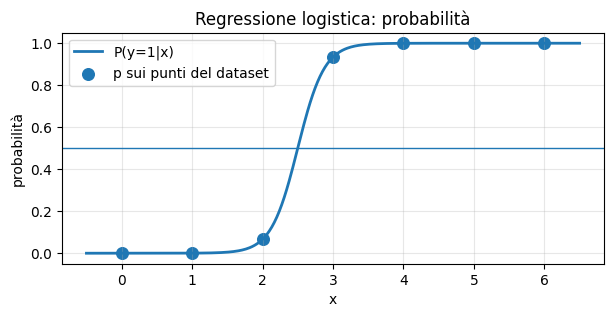

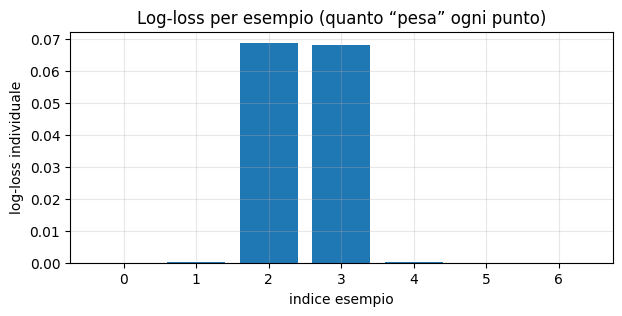

In [21]:
# Curva di probabilità
x_line = np.linspace(x.min()-0.5, x.max()+0.5, 400)
X_line = x_line.reshape(-1, 1)
p_line = model.predict_proba(X_line)[:, 1]

# Log-loss per ogni punto del dataset
loss_points = np.array([logistic_loss_single(yi, pi) for yi, pi in zip(y, p_train)])

plt.figure(figsize=(7,3))
plt.plot(x_line, p_line, linewidth=2, label="P(y=1|x)")
plt.axhline(0.5, linewidth=1)
plt.scatter(x, p_train, s=70, label="p sui punti del dataset")
plt.ylim(-0.05, 1.05)
plt.xlabel("x")
plt.ylabel("probabilità")
plt.title("Regressione logistica: probabilità")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7,3))
plt.bar(np.arange(len(x)), loss_points)
plt.xlabel("indice esempio")
plt.ylabel("log-loss individuale")
plt.title("Log-loss per esempio (quanto “pesa” ogni punto)")
plt.grid(True, alpha=0.3)
plt.show()


## 7) Messaggio chiave (da ricordare)

- La log-loss misura quanto una probabilità è “coerente” con la classe vera.
- Premia predizioni corrette e **sicure**.
- Penalizza tantissimo predizioni **sicure ma sbagliate**.
- È la loss naturale quando vogliamo output probabilistici per una classificazione binaria.

Per questo la regressione logistica (e molte reti neurali in classificazione) usano log-loss / cross-entropy.


## Esercizi

1. Cambia i valori di `p_pred` nella sezione 4 e osserva come cambia la log-loss.  
2. Prova a invertire una label nel dataset (es. cambia `y` per `x=2` da 0 a 1) e ricontrolla log-loss e probabilità.  
3. Prova una soglia diversa da 0.5 (es. 0.7) e confronta accuracy e log-loss: noterai che possono “raccontare cose diverse”.
